In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Titanic-Dataset.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [23]:
#cleaning the data
#handling the missing values

df['Age'] = df['Age'].fillna(df['Age'].median()) #finding the missing values from the table then filling those misssing values with median of that age

#inspection
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [31]:
#filling empty values with the frequent values
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [33]:
#the cabin column has too many missing values to be relevant, better to drop it
df.drop(columns = ['Cabin'], inplace = True)

In [36]:
#removing duplicates
df.drop_duplicates(inplace=True)

In [41]:
df['Pclass'] = df['Pclass'].astype(int)

In [42]:
df['Sex'] = df['Sex'].str.lower().str.strip()

In [43]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [38]:
#Who survived more: males or females?
gender_survival = df.groupby('Sex')['Survived'].value_counts()
print("Survival Count by Gender: \n",gender_survival)

Survival Count by Gender: 
 Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64


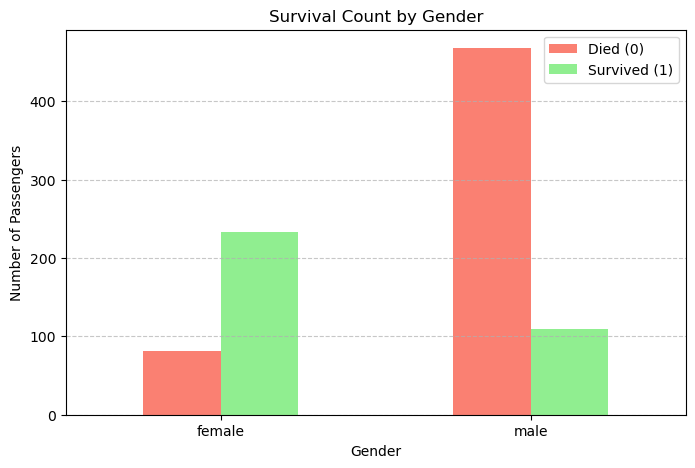

In [54]:
#visual representation
gender_survival.unstack().plot(kind='bar', color=['salmon', 'lightgreen'], figsize=(8, 5))

plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(['Died (0)', 'Survived (1)'])
plt.xticks(rotation=0)  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [50]:
#Did passenger class affect survival chances?
class_survival = df.groupby('Pclass')['Survived'].value_counts()
print("\nSurvival Count by Class: \n",class_survival)


Survival Count by Class: 
 Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64


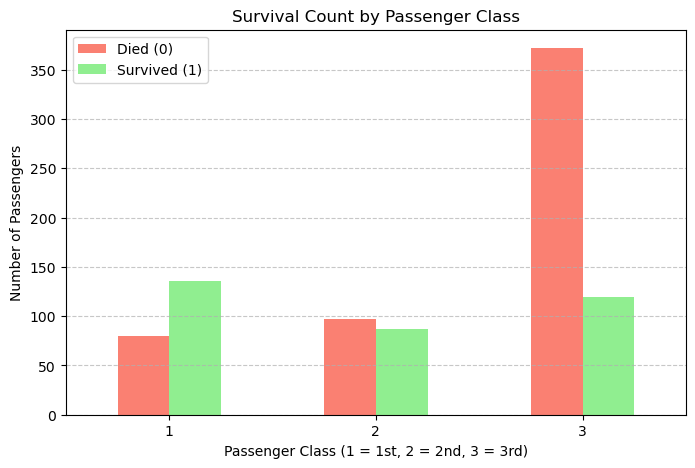

In [51]:
#visualization

class_survival.unstack().plot(kind='bar', color=['salmon', 'lightgreen'], figsize=(8, 5))

plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Number of Passengers')
plt.legend(['Died (0)', 'Survived (1)'])
plt.xticks(rotation=0)  # Keeps the class numbers upright
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [57]:
#What was the survival rate by age group?
# 1. Create age groups
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 2. Calculate survival rate by age group
# Update this specific line
age_survival = df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100

print("Survival Rate by Age Group:")
print(age_survival.round(2).astype(str) + '%')

Survival Rate by Age Group:
AgeGroup
Child          57.97%
Teen           42.86%
Young Adult    35.33%
Adult           40.0%
Senior         22.73%
Name: Survived, dtype: object


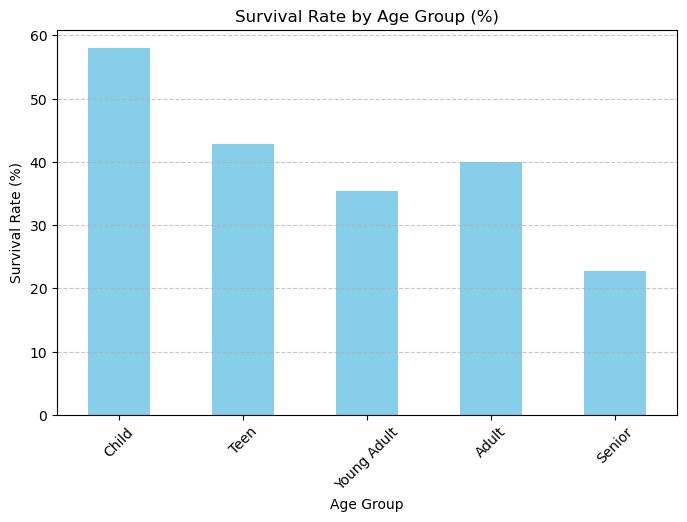

In [58]:
age_survival.plot(kind='bar', color='skyblue', figsize=(8, 5))

plt.title('Survival Rate by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
